In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller


# 1. Učitavanje celog fajla sa ispravnim enkodingom i separatorom
# Koristimo drugo ime za početni fajl da ne pregazimo tvoj 'df' odmah
full_data_raw = pd.read_csv('data/Train.csv', sep=';')

# 2. Filtriranje samo lančanih indeksa (mesečna inflacija)
temp_data = full_data_raw[full_data_raw['skrIndikator'].str.contains('Lančani', na=False)].copy()

# 3. Mapa za srpske mesece i konverzija datuma
meseci_map = {
    'januar': '01', 'februar': '02', 'mart': '03', 'april': '04', 
    'maj': '05', 'jun': '06', 'jul': '07', 'avgust': '08', 
    'septembar': '09', 'oktobar': '10', 'novembar': '11', 'decembar': '12'
}

def konvertuj(tekst):
    try:
        godina, mesec = str(tekst).split('/')
        return f"{godina}-{meseci_map[mesec]}-01"
    except:
        return None

temp_data['nVrTacka'] = temp_data['nVrTacka'].apply(konvertuj)
temp_data['nVrTacka'] = pd.to_datetime(temp_data['nVrTacka'])

# 4. Sortiranje i računanje stope inflacije
temp_data = temp_data[['nVrTacka', 'Vrednost']].dropna().sort_values('nVrTacka').set_index('nVrTacka')
temp_data['Inflacija'] = temp_data['Vrednost'] - 100
temp_data = temp_data.asfreq('MS')

# 5. KLJUČNI KORAK: Podela na 80% i dodela imena 'df'
# Ovim osiguravamo da tvoja dosadašnja analiza na 'df' radi samo na trening podacima
split_point = int(len(temp_data) * 0.8)

df = temp_data.iloc[:split_point]      # Tvoj glavni set za analizu (80%)
test_df = temp_data.iloc[split_point:] # Ostatak za proveru (20%)



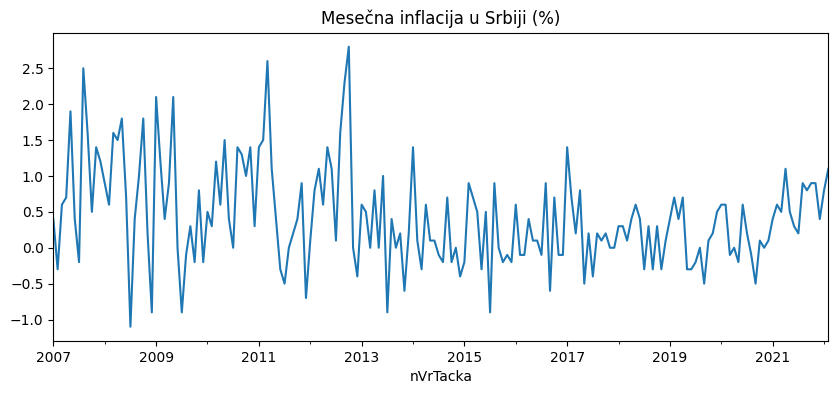

In [13]:
df['Inflacija'].plot(figsize=(10,4), title='Mesečna inflacija u Srbiji (%)')
plt.show()

In [26]:
adf_result = adfuller(df['Inflacija'].dropna())
adf_value = adf_result[0]
p_value = adf_result[1]

print(f'{adf_value=:.2f}, {p_value=:.2f}')

if p_value <= 0.05:
    print('postoji stacionarnost')
else:
    print('ne postoji stacionarnost')

adf_value=-2.79, p_value=0.06
ne postoji stacionarnost


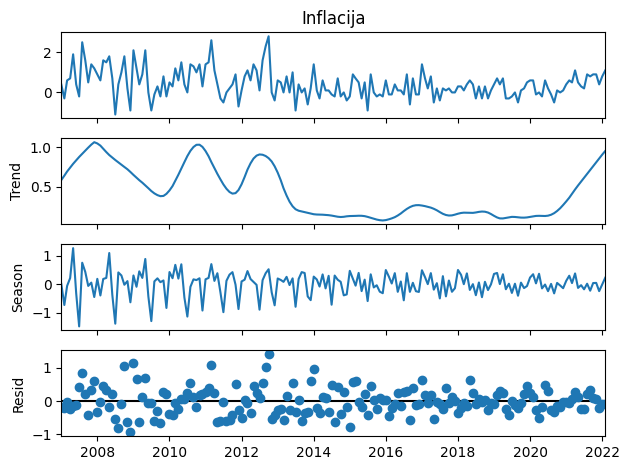

In [15]:
from statsmodels.tsa.seasonal import STL
stl = STL(df['Inflacija']).fit()
stl.plot()
plt.show()

ADF statistika: -7.1814
p-value: 0.0000
Serija je sada stacionarna.


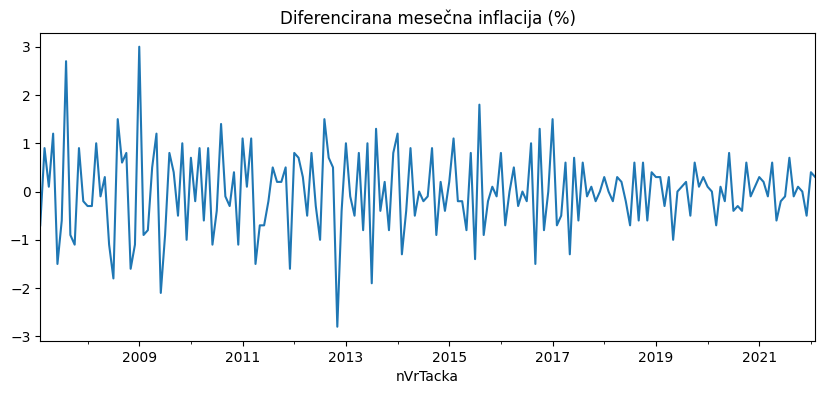

In [16]:

# Prvo diferenciranje
stationary_data = df['Inflacija'].diff().dropna()

# ADF test na diferenciranoj seriji
result = adfuller(stationary_data)

print(f"ADF statistika: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

if result[1] <= 0.05:
    print("Serija je sada stacionarna.")
else:
    print("Serija i dalje nije stacionarna.")

# Graf diferencirane serije
stationary_data.plot(figsize=(10,4), title='Diferencirana mesečna inflacija (%)')
plt.show()

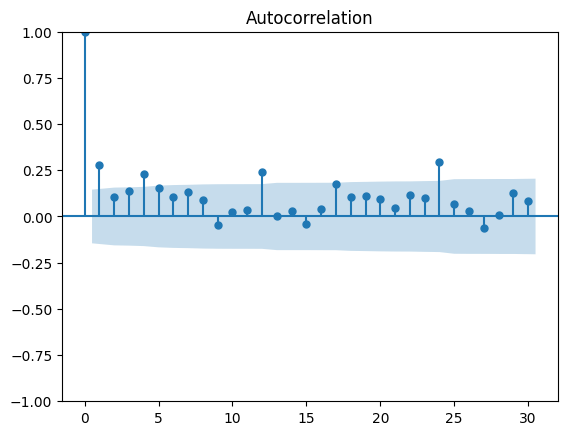

In [17]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df['Inflacija'], lags=30)
plt.show()

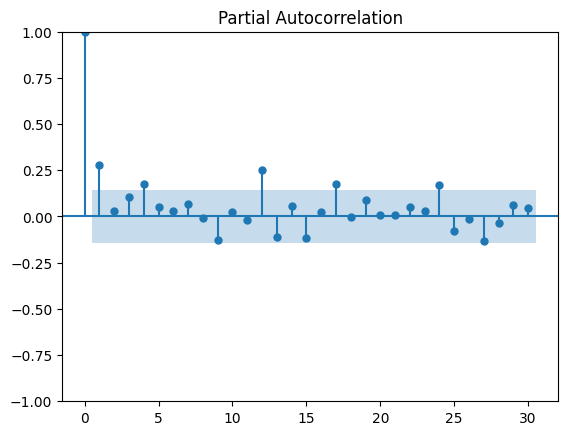

In [18]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df['Inflacija'], lags=30)
plt.show()

In [19]:
result = acorr_ljungbox(stationary_data, lags=15, return_df=True)
result

,lb_stat,lb_pvalue
1,26.379629,2.804831e-07
2,30.036424,3.003817e-07
3,30.426471,1.122458e-06
4,32.897369,1.253689e-06
5,32.935392,3.876251e-06
6,33.540056,8.252560e-06
7,34.080930,1.663423e-05
8,34.920118,2.764930e-05
9,39.032750,1.136497e-05
10,39.311430,2.239009e-05


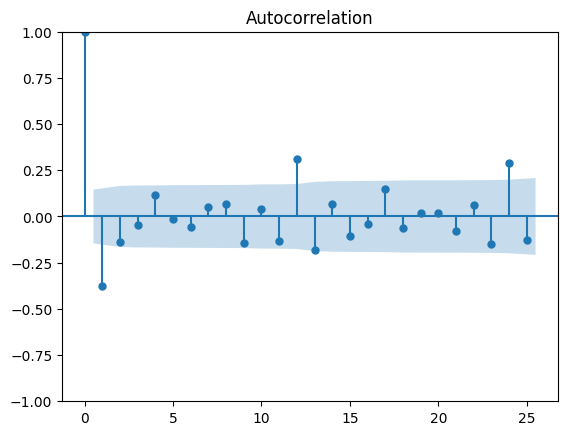

In [20]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(stationary_data, lags=25)
plt.show()

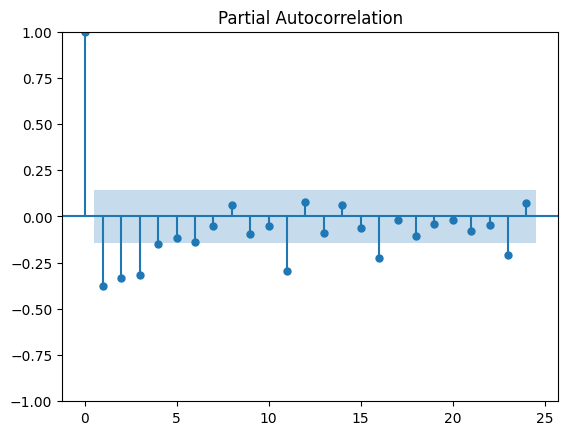

In [21]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(stationary_data, lags=24, method='ols')
plt.show()

                                     SARIMAX Results                                      
Dep. Variable:                          Inflacija   No. Observations:                  182
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -137.567
Date:                            Sun, 15 Mar 2026   AIC                            283.133
Time:                                    14:29:02   BIC                            295.307
Sample:                                01-01-2007   HQIC                           288.078
                                     - 02-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2957      0.086      3.453      0.001       0.128       0.464
ma.L1         -0.9433      0.047   

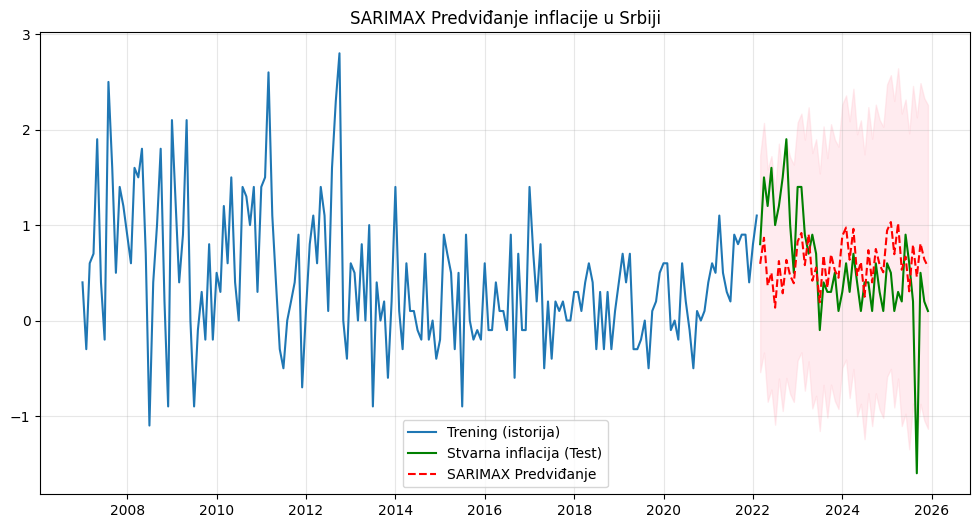

In [22]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Definisanje SARIMAX modela
# Redosled (p, d, q) je za trend, a (P, D, Q, s) je za sezonalnost (12 meseci)
# Ove parametre (1,1,1) uzimamo kao polaznu tačku za inflaciju
model = sm.tsa.statespace.SARIMAX(df['Inflacija'],
                                order=(1, 0, 1),              # (p, d, q)
                                seasonal_order=(0, 1, 1, 12),   # (P, D, Q, s)
                                enforce_stationarity=False,
                                enforce_invertibility=False)

# 2. Treniranje modela (Fitting)
results = model.fit()

# 4. Predviđanje (Forecasting) na test skupu (onih 20% što smo odvojili)
forecast = results.get_forecast(steps=len(test_df))
forecast_df = forecast.summary_frame()

# 5. Vizuelizacija rezultata
plt.figure(figsize=(12, 6))
plt.plot(df['Inflacija'], label='Trening (istorija)')
plt.plot(test_df['Inflacija'], label='Stvarna inflacija (Test)', color='green')
plt.plot(forecast_df['mean'], label='SARIMAX Predviđanje', color='red', linestyle='--')

# Senka za interval poverenja (Confidence Interval)
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], color='pink', alpha=0.3)

plt.title('SARIMAX Predviđanje inflacije u Srbiji')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
mae = mean_absolute_error(test_df['Inflacija'], forecast_df['mean'])
print(f"MAE: {mae:.2f}%")


rmse = np.sqrt(mean_squared_error(test_df['Inflacija'], forecast_df['mean']))
print(f"RMSE: {rmse:.2f}%")

MAE: 0.47%
RMSE: 0.59%


In [24]:
naive_predictions = [df['Inflacija'].iloc[-1]]  
for t in range(1, len(test_df)):
    naive_predictions.append(test_df['Inflacija'].iloc[t-1])

mae_naive = mean_absolute_error(test_df['Inflacija'], naive_predictions)
rmse_naive = np.sqrt(mean_squared_error(test_df['Inflacija'], naive_predictions))
print(f"Naivni model → MAE: {mae_naive:.2f}%, RMSE: {rmse_naive:.2f}%")



Naivni model → MAE: 0.41%, RMSE: 0.57%
